In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as c

In [79]:
# load the data
fp = '/data2/hoppener/radio-astronomy-by-notebooks/working_class_3/'
file_cold_load = 'HI_measurement_n1_cold'
file_hot = 'HI_measurement_n2_hot'
file_vega = 'HI_measurement_n3_vega'

# load as np.array
cold_load = np.fromfile(fp + file_cold_load, dtype=np.float32)
hot_load = np.fromfile(fp + file_hot, dtype=np.float32) 
vega = np.fromfile(fp + file_vega, dtype=np.float32) 


In [80]:
# define GNU radio constants
samp_rate = 16*10**6
center_frequency = 1.417e9
dt = 1/samp_rate

# reshape the autocorrelation data, starting each new integration on a new line
vector_length = 2**15
N_spectra = cold_load.size // vector_length # number of integrated spectra
cold_load_spectra = cold_load.reshape(N_spectra, vector_length)
cold_load_spectra = np.mean(cold_load_spectra, axis=0) 

# calculate the autocorrelator frequency
frequency = np.fft.fftfreq(vector_length, d=dt)
frequency = np.fft.fftshift(frequency) + center_frequency # center around 1.42Ghz


[]

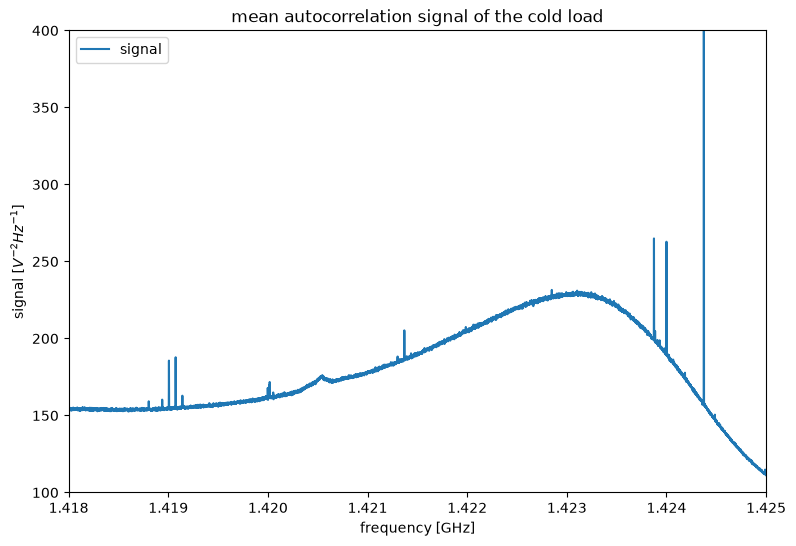

In [81]:
# visualise the mean autocorrelated signal
plt.figure(figsize=(9,6))
plt.title('mean autocorrelation signal of the cold load')
plt.plot(frequency/1e9, cold_load_spectra, label = 'signal')
plt.xlabel("frequency [GHz]")
plt.ylabel("signal [$V^{-2}Hz^{-1}$]")
plt.xlim(1.418, 1.425)
plt.ylim(100,400)
plt.legend()
plt.plot()

In [82]:
N_spectra = hot_load.size // vector_length # number of integrated spectra
hot_load_spectra = hot_load.reshape(N_spectra, vector_length)
hot_load_spectra = np.mean(hot_load_spectra, axis=0) 

# calculate the autocorrelator frequency
frequency = np.fft.fftfreq(vector_length, d=dt)
frequency = np.fft.fftshift(frequency) + center_frequency # center around 1.42Ghz


[]

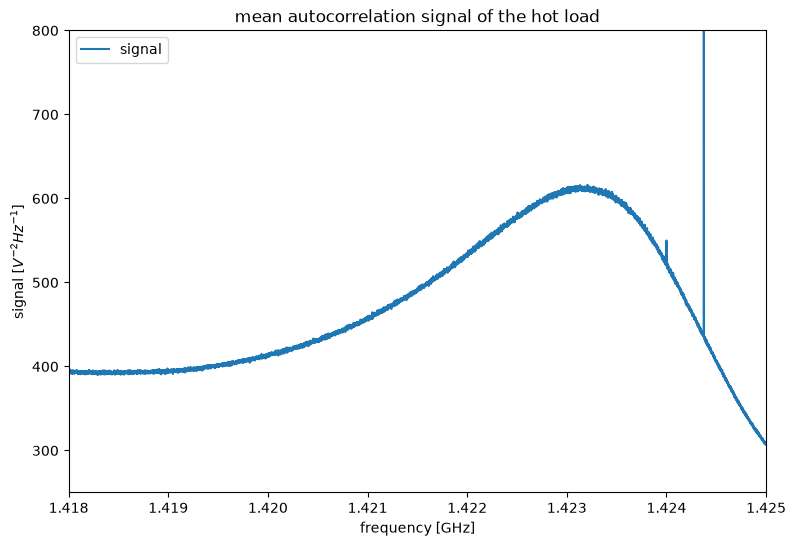

In [83]:
# visualise the mean autocorrelated signal
plt.figure(figsize=(9,6))
plt.title('mean autocorrelation signal of the hot load')
plt.plot(frequency/1e9, hot_load_spectra, label = 'signal')
plt.xlabel("frequency [GHz]")
plt.ylabel("signal [$V^{-2}Hz^{-1}$]") # not shure about units
plt.xlim(1.418, 1.425)
plt.ylim(250,800)
plt.legend()
plt.plot()

In [84]:
N_spectra = vega.size // vector_length # number of integrated spectra
vega_spectra = vega.reshape(N_spectra, vector_length) 
vega_spectra = np.mean(vega_spectra, axis=0) 

# calculate the autocorrelator frequency
frequency = np.fft.fftfreq(vector_length, d=dt)
frequency = np.fft.fftshift(frequency) + center_frequency # center around 1.42Ghz
print(N_spectra)

154


[]

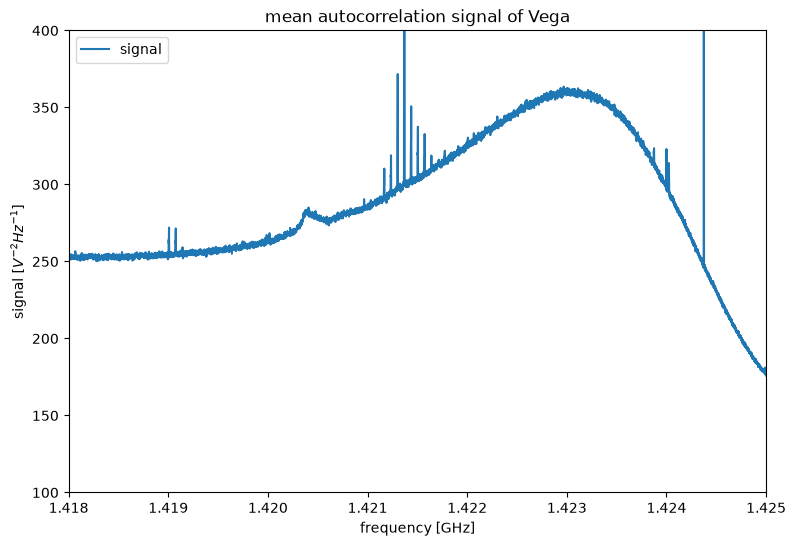

In [94]:
# visualise the mean autocorrelated signal
plt.figure(figsize=(9,6))
plt.title('mean autocorrelation signal of Vega')
plt.plot(frequency/1e9, vega_spectra, label = 'signal')
plt.xlabel("frequency [GHz]")
plt.ylabel("signal [$V^{-2}Hz^{-1}$]") # not shure about units
plt.xlim(1.418, 1.425)
plt.ylim(100,400)
plt.legend()
plt.plot()

In [95]:
# Y-factor calibration (formula's from essential radio astronomy book)
T_hot = 295 # temperature of the microwave absorber
T_cold = 10 # system temperature = T_cmb + T_rsb(sky brightness) + T_atm + T_spill + T_radiometer
Y = hot_load_spectra/cold_load_spectra
noise_temp = (T_hot-Y*T_cold)/(Y-1)
P_mu = noise_temp*c.k_B # noise power

# conversion from voltage to temperature (source: https://www.aoc.nrao.edu/evla/geninfo/memoseries/evlamemo90.pdf)
G = (hot_load_spectra - cold_load_spectra) / (T_hot - T_cold) 
T_source = (vega_spectra / G) - noise_temp

[]

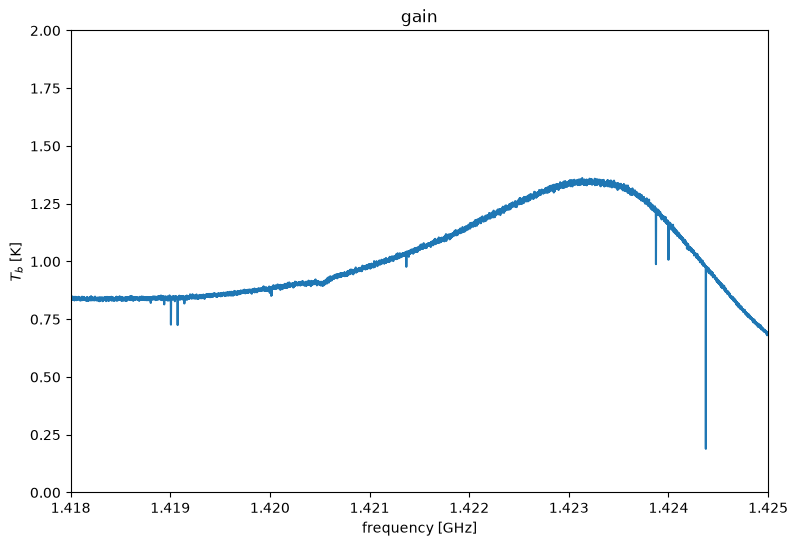

In [96]:
# plot the brightness temperature of the source against frequency
plt.figure(figsize=(9,6))
plt.title('gain')
plt.plot(frequency/1e9, G)
plt.xlabel("frequency [GHz]")
plt.ylabel("$T_b$ [K]") 
plt.xlim(1.418, 1.425)
plt.ylim(0,2)
plt.plot()

[]

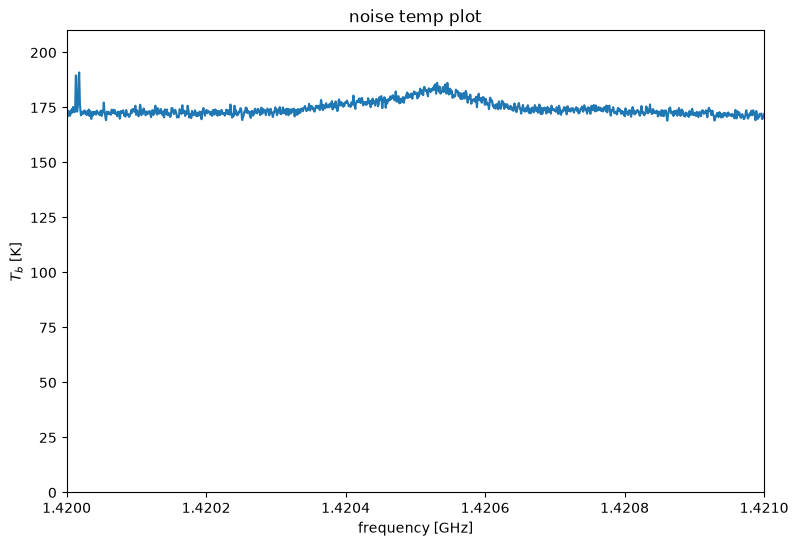

In [97]:
# plot the brightness temperature of the source against frequency
plt.figure(figsize=(9,6))
plt.title('noise temp plot')
plt.plot(frequency/1e9, noise_temp)
plt.xlabel("frequency [GHz]")
plt.ylabel("$T_b$ [K]") 
plt.xlim(1.420, 1.421)
plt.ylim(0,210)
plt.plot()

[]

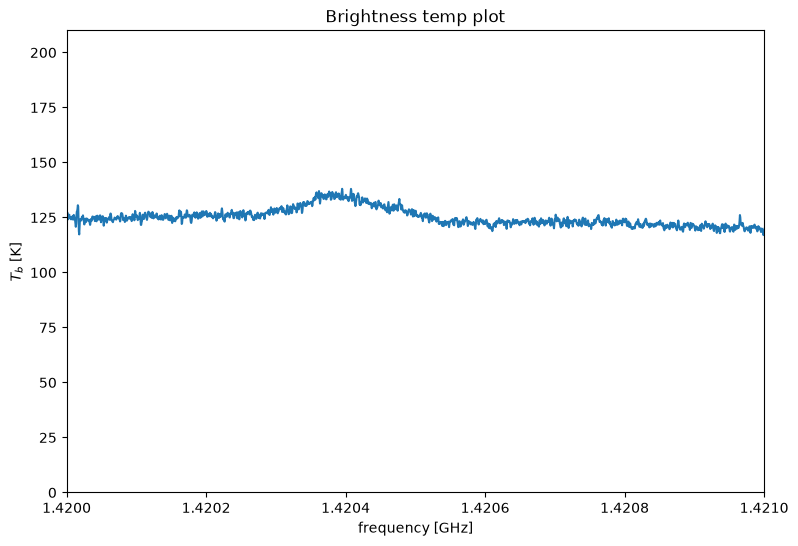

In [98]:
# plot the brightness temperature of the source against frequency
plt.figure(figsize=(9,6))
plt.title('Brightness temp plot')
plt.plot(frequency/1e9, T_source)
plt.xlabel("frequency [GHz]")
plt.ylabel("$T_b$ [K]") 
plt.xlim(1.420, 1.421)
plt.ylim(0,210)
plt.plot()